In [7]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rc('figure',  figsize=(20, 10))
mpl.rc('image', cmap='gray')


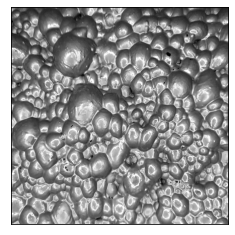

In [2]:
img = cv2.imread('./bubble_raw.png')
b,g,r = cv2.split(img)
rgb_img = cv2.merge([r,g,b])

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

plt.imshow(gray)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()


ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

In [3]:
def display_img(image):
  plt.imshow(image)
  plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
  plt.show()

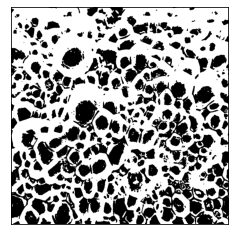

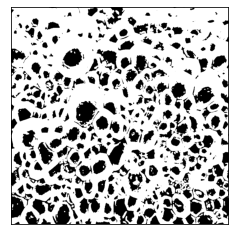

In [4]:
# noise removal
kernel = np.ones((2,2),np.uint8)
#opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel, iterations = 2)
closing = cv2.morphologyEx(thresh,cv2.MORPH_CLOSE,kernel, iterations = 2)

display_img(closing)

# sure background area
sure_bg = cv2.dilate(closing,kernel,iterations=3)
display_img(sure_bg)


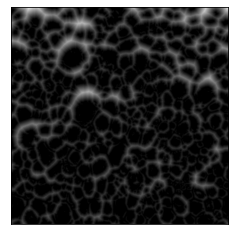

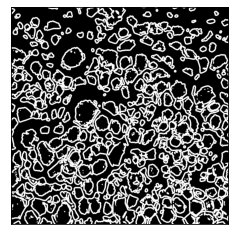

In [5]:
# Finding sure foreground area
dist_transform = cv2.distanceTransform(sure_bg,cv2.DIST_L2,3)
display_img(dist_transform)
# Threshold
ret, sure_fg = cv2.threshold(dist_transform,0.1*dist_transform.max(),255,0)

# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)

display_img(unknown)



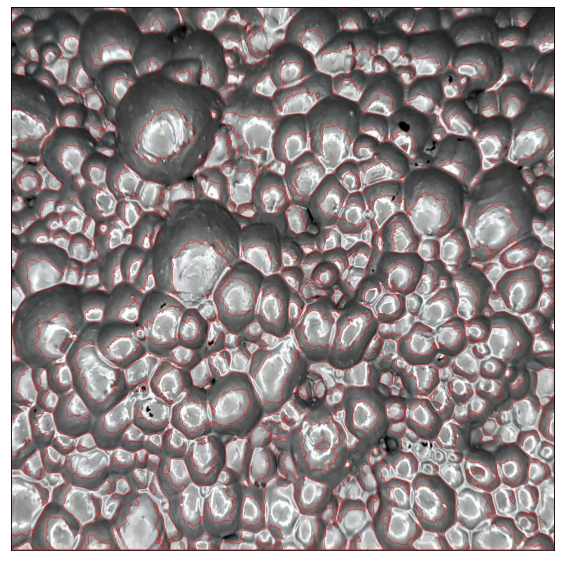

In [8]:
# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers+1




# mark the region of unknown with zero
markers[unknown==255] = 0

markers = cv2.watershed(img,markers)
img[markers == -1] = [255,0,0]
img1 = img
display_img(img)



In [ ]:

fg = cv2.erode(thresh,None,iterations = 1)
display_img(fg)



In [ ]:
bgt = cv2.dilate(thresh,None,iterations = 5)
ret,bg = cv2.threshold(bgt,1,128,1)
display_img(bg)


In [ ]:
marker = cv2.add(fg,bg)
display_img(marker)



In [ ]:
marker32 = np.int32(marker)

cv2.watershed(img,marker32)
m = cv2.convertScaleAbs(marker32)
display_img(m)


In [ ]:
ret,thresh = cv2.threshold(m,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
res = cv2.bitwise_and(img,img,mask = thresh)
display_img(res)
